In [2]:
# Setup — install only on Colab; local execution uses the repository .venv.
import sys
if "google.colab" in sys.modules:
    %pip install -q torch torchvision matplotlib numpy

In [3]:
from pathlib import Path
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.datasets import OxfordIIITPet

SEED = 17
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
# Local: point OXFORD_PET_ROOT at the instructor-cached data directory.
DATA_ROOT = Path("/content/oxford-pet-data") if "google.colab" in sys.modules else Path(os.environ.get("OXFORD_PET_ROOT", "data"))
raw_dataset = OxfordIIITPet(root=DATA_ROOT, split="trainval", target_types="segmentation", download=True)
TEACHING_INDICES = [17, 112, 389, 744, 1098, 1621]
print(f"Loaded {len(raw_dataset)} train/validation pairs from {DATA_ROOT.resolve()}")
print("Fixed teaching indices:", TEACHING_INDICES)

100%|██████████| 792M/792M [00:36<00:00, 21.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.4MB/s]


Loaded 3680 train/validation pairs from /content/oxford-pet-data
Fixed teaching indices: [17, 112, 389, 744, 1098, 1621]


## 1. Three ways to label one picture

The class name answers *which animal is present*. A rough box answers *approximately where it is*. The trimap answers *which label belongs at each pixel*. Only the trimap can supervise semantic segmentation.

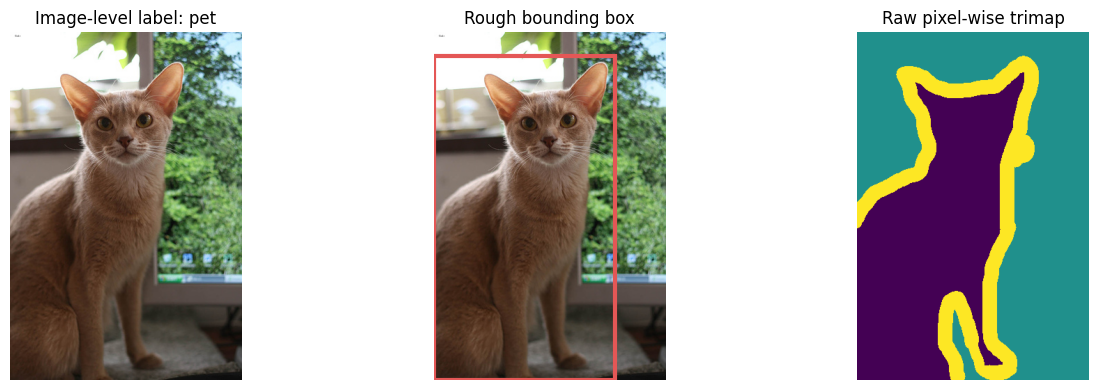

In [4]:
def rough_box_from_trimap(trimap):
    """Display-only box around pet and uncertain border; not a segmentation target."""
    arr = np.asarray(trimap)
    ys, xs = np.where(arr != 2)  # raw: 1=pet, 2=background, 3=border
    return xs.min(), ys.min(), xs.max() - xs.min(), ys.max() - ys.min()

image, trimap = raw_dataset[TEACHING_INDICES[0]]
box = rough_box_from_trimap(trimap)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(image); axes[0].set_title("Image-level label: pet")
axes[1].imshow(image); axes[1].add_patch(plt.Rectangle((box[0], box[1]), box[2], box[3], fill=False, ec="#e45756", lw=3)); axes[1].set_title("Rough bounding box")
axes[2].imshow(trimap, cmap="viridis", vmin=1, vmax=3); axes[2].set_title("Raw pixel-wise trimap")
for ax in axes: ax.axis("off")
plt.tight_layout()

## 2. Inspect aligned pairs

A correct image–mask pair has the same height and width. Raw trimap values are dataset annotation IDs: `1=pet`, `2=background`, and `3=border`. They are not yet the zero-based class IDs a model expects.

index=17: image=(500, 333, 3), trimap=(500, 333), dtype=uint8, values=[1, 2, 3]
index=112: image=(225, 300, 3), trimap=(225, 300), dtype=uint8, values=[1, 2, 3]
index=389: image=(600, 909, 3), trimap=(600, 909), dtype=uint8, values=[1, 2, 3]


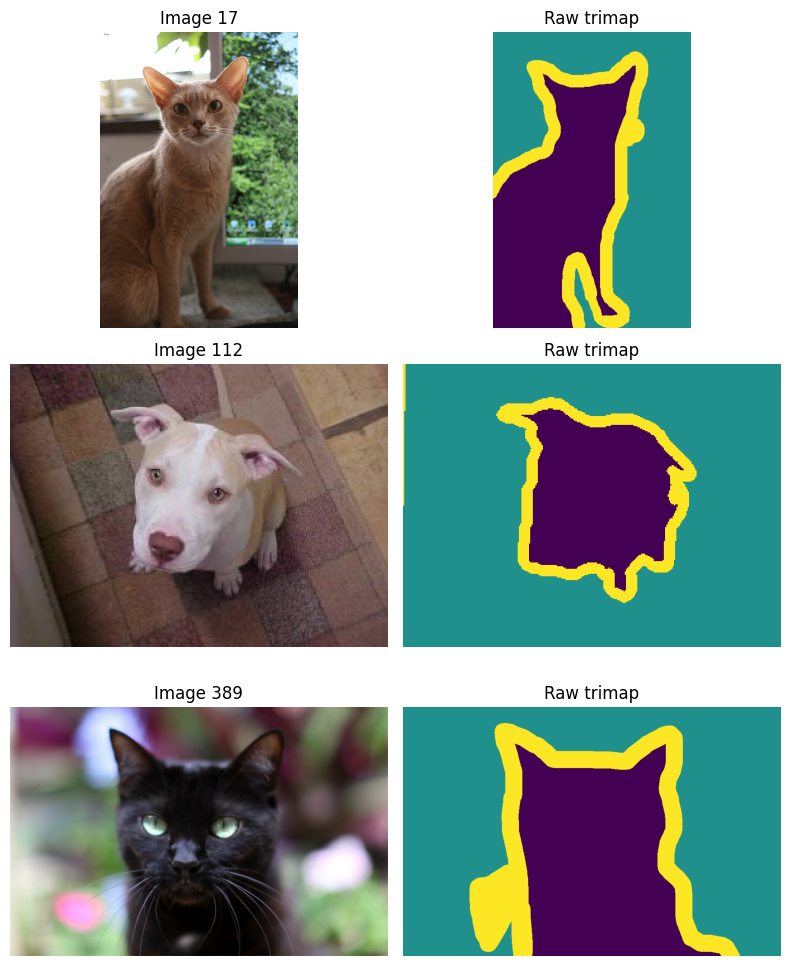

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
for row, index in enumerate(TEACHING_INDICES[:3]):
    image, trimap = raw_dataset[index]
    arr = np.asarray(trimap)
    print(f"index={index}: image={np.asarray(image).shape}, trimap={arr.shape}, dtype={arr.dtype}, values={np.unique(arr).tolist()}")
    axes[row, 0].imshow(image); axes[row, 0].set_title(f"Image {index}")
    axes[row, 1].imshow(trimap, cmap="viridis", vmin=1, vmax=3); axes[row, 1].set_title("Raw trimap")
    for ax in axes[row]: ax.axis("off")
plt.tight_layout()

## 3. Exercise E1 — remap the trimap

Complete `remap_trimap`. Preserve the uncertain raw border as `255`, the ignore value used later by loss functions and metrics. The function must return `torch.int64` and allow *only* `{0, 1, 255}`.

In [6]:
# TODO: Return an int64 tensor using 0=background, 1=pet, 255=border/ignore.
# HINT: Raw values are 1=pet, 2=background, 3=border. Build the output explicitly.


In [7]:
def remap_trimap(trimap):
    arr = np.asarray(trimap)

    remap = np.full(arr.shape, 255, dtype=np.int64)
    remap[arr == 2] = 0
    remap[arr == 1] = 1

    return torch.from_numpy(remap).long()

In [8]:
for index in TEACHING_INDICES[:3]:
    _, trimap = raw_dataset[index]
    target = remap_trimap(trimap)
    counts = {"background (0)": int((target == 0).sum()), "pet (1)": int((target == 1).sum()), "ignored border (255)": int((target == 255).sum())}
    print(f"index={index}: dtype={target.dtype}; values={target.unique().tolist()}; {counts}")

index=17: dtype=torch.int64; values=[0, 1, 255]; {'background (0)': 80032, 'pet (1)': 60766, 'ignored border (255)': 25702}
index=112: dtype=torch.int64; values=[0, 1, 255]; {'background (0)': 50411, 'pet (1)': 11979, 'ignored border (255)': 5110}
index=389: dtype=torch.int64; values=[0, 1, 255]; {'background (0)': 302323, 'pet (1)': 160219, 'ignored border (255)': 82858}


## 4. Make the target readable

A color display makes alignment easy to inspect: navy is background, orange is pet, and yellow is the ignored boundary. If the orange silhouette does not sit on the pet in the photograph, stop: the pair has been corrupted.

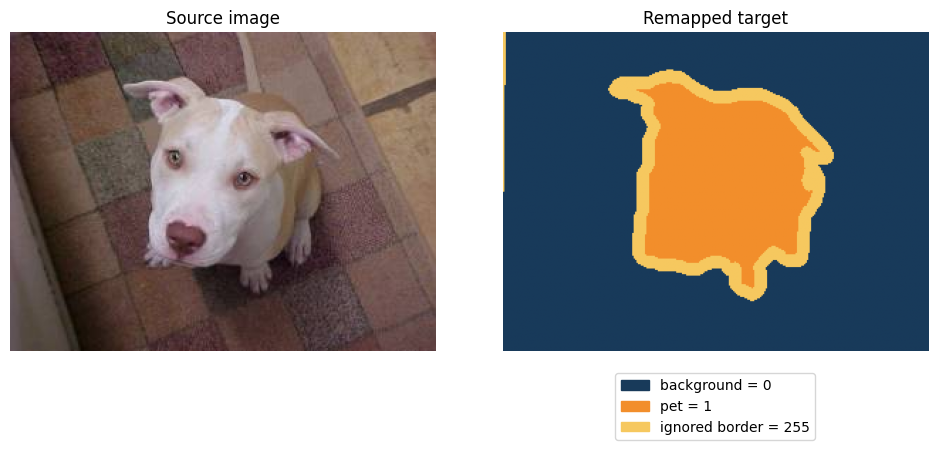

In [9]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
DISPLAY_CMAP = ListedColormap(["#183a5a", "#f28e2b", "#f6c85f"])
def color_target(target):
    display = target.clone(); display[target == 255] = 2
    return display
image, trimap = raw_dataset[TEACHING_INDICES[1]]
target = remap_trimap(trimap)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image); axes[0].set_title("Source image")
axes[1].imshow(color_target(target), cmap=DISPLAY_CMAP, vmin=0, vmax=2); axes[1].set_title("Remapped target")
axes[1].legend(handles=[Patch(color="#183a5a", label="background = 0"), Patch(color="#f28e2b", label="pet = 1"), Patch(color="#f6c85f", label="ignored border = 255")], loc="lower center", bbox_to_anchor=(0.5, -0.3))
for ax in axes: ax.axis("off")
plt.tight_layout()

> TODO: In 2–3 sentences, caption the pair above. Identify the pet, the background, and the ignored border. Explain why the ignored border is not a third semantic class.


La máscara remapeada identifica el fondo con la etiqueta 0, la mascota con la etiqueta 1 y el borde ambiguo con 255. El borde no es una tercera clase porque no corresponde a un objeto diferente, sino a una zona de incertidumbre entre la mascota y el fondo; por esta razón se ignora durante el entrenamiento y la evaluación.

## 5. Record the data contract

Later sessions resize a pair to 128×128. The input has three RGB channels; the target is one integer label per pixel; a two-class model emits one logit map per class.

In [10]:
image_shape = [3, 128, 128]
mask_shape = [128, 128]
future_logits_shape = [2, 128, 128]
print("Data contract for one 128×128 example")
print("image:        ", image_shape, "(RGB channels, height, width)")
print("target mask:  ", mask_shape, "(one class ID per pixel)")
print("future logits:", future_logits_shape, "(background and pet score maps)")

Data contract for one 128×128 example
image:         [3, 128, 128] (RGB channels, height, width)
target mask:   [128, 128] (one class ID per pixel)
future logits: [2, 128, 128] (background and pet score maps)


## Wrap-up

You saw why segmentation needs a pixel-wise target, remapped Oxford-IIIT Pet trimaps without inventing a border class, and checked that labels remain spatially aligned with their images. Next session: transformations must move the image and mask together.